In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import numpy as np

In [24]:
day = pd.read_csv("day.csv")

In [25]:
columns_to_drop = ['instant','dteday','casual','registered','yr']
day = day.drop(columns_to_drop, axis=1)

In [26]:
X = day.drop('cnt', axis=1)
y = day['cnt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
model_day = RandomForestRegressor(n_estimators=400, random_state=42)
model_day.fit(X_train, y_train)


RandomForestRegressor(n_estimators=400, random_state=42)

In [28]:
y_pred_day = model_day.predict(X_test)

In [29]:
r2_day = r2_score(y_test, y_pred_day)
rmse_day = np.sqrt(mean_squared_error(y_test, y_pred_day))
mae_day = mean_absolute_error(y_test, y_pred_day)

print("DAY Dataset Model Performance:")
print("R² Score: ", r2_day)
print("RMSE: ", rmse_day)
print("MAE: ", mae_day)

DAY Dataset Model Performance:
R² Score:  0.5815781329879008
RMSE:  1295.3078528627238
MAE:  1078.834829931973


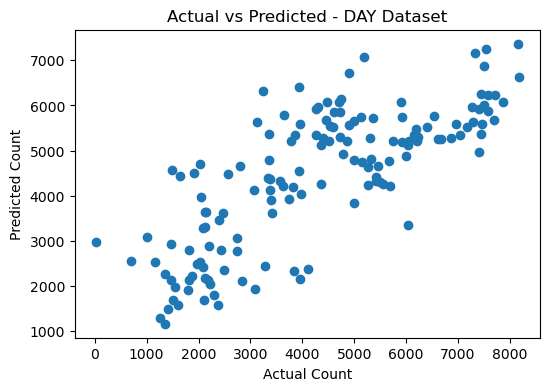

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_day)
plt.title("Actual vs Predicted - DAY Dataset")
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.show()

In [32]:
hour = pd.read_csv("hour.csv")

In [33]:
columns_to_drop_h = ['instant','dteday','casual','yr']
hour = hour.drop(columns_to_drop_h, axis=1)

In [34]:
Xh = hour.drop('cnt', axis=1)
yh = hour['cnt']

Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=42)

In [35]:
model_hour = RandomForestRegressor(n_estimators=400, random_state=42)
model_hour.fit(Xh_train, yh_train)


RandomForestRegressor(n_estimators=400, random_state=42)

In [36]:
yh_pred = model_hour.predict(Xh_test)

In [37]:
r2_hour = r2_score(yh_test, yh_pred)
rmse_hour = np.sqrt(mean_squared_error(yh_test, yh_pred))
mae_hour = mean_absolute_error(yh_test, yh_pred)

print("HOUR Dataset Model Performance:")
print("R² Score: ", r2_hour)
print("RMSE: ", rmse_hour)
print("MAE: ", mae_hour)

HOUR Dataset Model Performance:
R² Score:  0.9909255953413028
RMSE:  16.951246448303074
MAE:  9.796814585730726


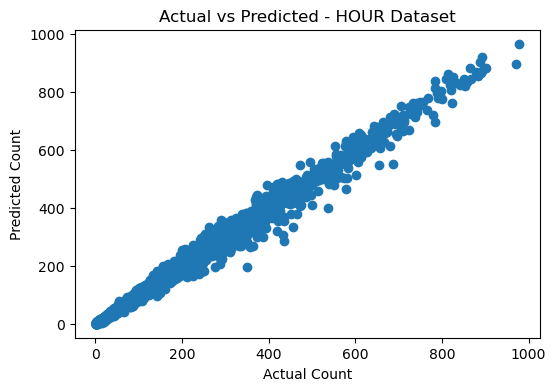

In [38]:
plt.figure(figsize=(6,4))
plt.scatter(yh_test, yh_pred)
plt.title("Actual vs Predicted - HOUR Dataset")
plt.xlabel("Actual Count")
plt.ylabel("Predicted Count")
plt.show()


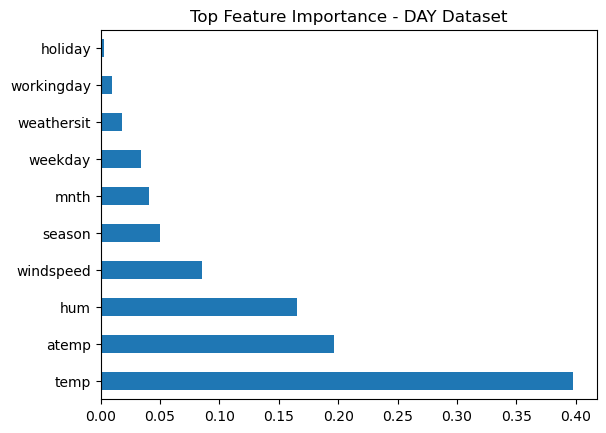

In [39]:
feat_imp = pd.Series(model_day.feature_importances_, index=X.columns)
feat_imp.nlargest(10).plot(kind='barh')
plt.title("Top Feature Importance - DAY Dataset")
plt.show()


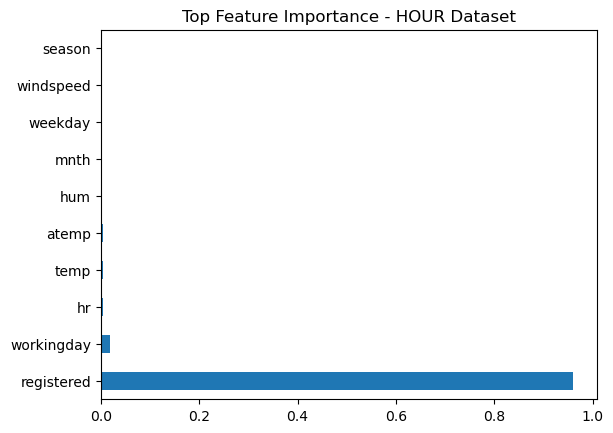

In [40]:
feat_imp2 = pd.Series(model_hour.feature_importances_, index=Xh.columns)
feat_imp2.nlargest(10).plot(kind='barh')
plt.title("Top Feature Importance - HOUR Dataset")
plt.show()

In [41]:
combined = pd.concat([day, hour], axis=0, ignore_index=True)

Xc = combined.drop('cnt', axis=1)
yc = combined['cnt']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

model_combined = RandomForestRegressor(n_estimators=300, random_state=42)
model_combined.fit(Xc_train, yc_train)

yc_pred = model_combined.predict(Xc_test)
r2_combined = r2_score(yc_test, yc_pred)
print("Combined Model Accuracy (R2 Score): ", r2_combined)

Combined Model Accuracy (R2 Score):  0.9247894034599999
